# XGBoost Hyperparameter Tuning

## Objective

The baseline XGBoost model demonstrated strong predictive performance. The objective of this notebook is to optimize its hyperparameters using RandomizedSearchCV and evaluate whether tuning improves the model's predictive performance and generalization capability.

In [1]:
import json
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
processed_dir = Path("../data/processed")
models_dir = Path("../models")
results_dir = Path("../results")

x_train = joblib.load(processed_dir / "x_train_processed.pkl")
x_test = joblib.load(processed_dir / "x_test_processed.pkl")

y_train = joblib.load(processed_dir / "y_train.pkl")
y_test = joblib.load(processed_dir / "y_test.pkl")

In [3]:
with open(results_dir / "xgboost_metrics.json") as f:
    baseline_metrics = json.load(f)

In [4]:
xgb = XGBClassifier(random_state=1, eval_metric="logloss")

In [5]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

In [6]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=1,
    n_jobs=-1
)

In [7]:
random_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.

In [8]:
random_search.best_params_

{'subsample': 0.9,
 'n_estimators': 100,
 'max_depth': 3,
 'learning_rate': 0.05,
 'colsample_bytree': 0.9}

In [9]:
random_search.best_score_

np.float64(0.8490586053592686)

In [10]:
best_xgb = random_search.best_estimator_

best_xgb

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
y_pred = best_xgb.predict(x_test)

y_prob = best_xgb.predict_proba(x_test)[:, 1]

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [13]:
xgb_tuned_metrics = {
    "Model": "XGBoost (Tuned)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

xgb_tuned_metrics

{'Model': 'XGBoost (Tuned)',
 'Accuracy': 0.7917555081734187,
 'Precision': 0.6494464944649446,
 'Recall': 0.47058823529411764,
 'F1 Score': 0.5457364341085271,
 'ROC-AUC': 0.8346426223397921}

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1033
           1       0.65      0.47      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



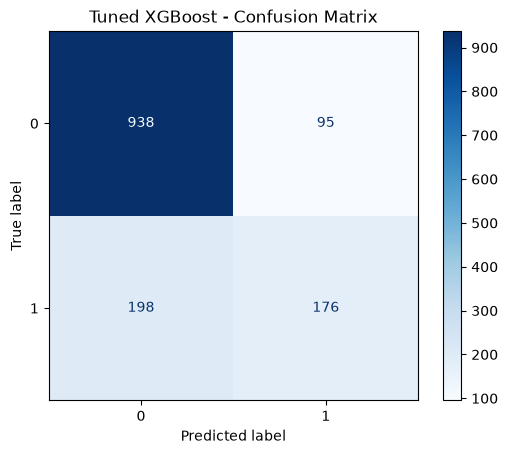

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

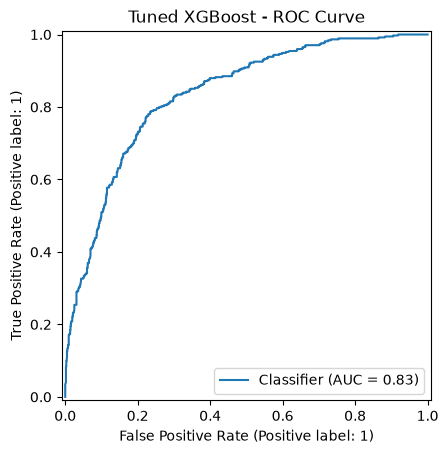

In [16]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Tuned XGBoost - ROC Curve")
plt.show()

In [17]:
tuned_models_dir = Path("../models/tuned")
tuned_models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_xgb,
    tuned_models_dir / "xgboost_tuned.pkl"
)

['..\\models\\tuned\\xgboost_tuned.pkl']

In [18]:
tuned_results_dir = Path("../results/tuned")
tuned_results_dir.mkdir(parents=True, exist_ok=True)

with open(
    tuned_results_dir / "xgboost_tuned_metrics.json",
    "w"
) as f:
    json.dump(xgb_tuned_metrics, f, indent=4)

In [19]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Baseline": [
        baseline_metrics["Accuracy"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1 Score"],
        baseline_metrics["ROC-AUC"]
    ],
    "Tuned": [
        xgb_tuned_metrics["Accuracy"],
        xgb_tuned_metrics["Precision"],
        xgb_tuned_metrics["Recall"],
        xgb_tuned_metrics["F1 Score"],
        xgb_tuned_metrics["ROC-AUC"]
    ]
})

comparison_df["Improvement"] = (
    comparison_df["Tuned"] -
    comparison_df["Baseline"]
).round(6)

comparison_df

,Metric,Baseline,Tuned,Improvement
0,Accuracy,0.786070,0.791756,0.005686
1,Precision,0.618893,0.649446,0.030554
2,Recall,0.508021,0.470588,-0.037433
3,F1 Score,0.558003,0.545736,-0.012267
4,ROC-AUC,0.804683,0.834643,0.029959


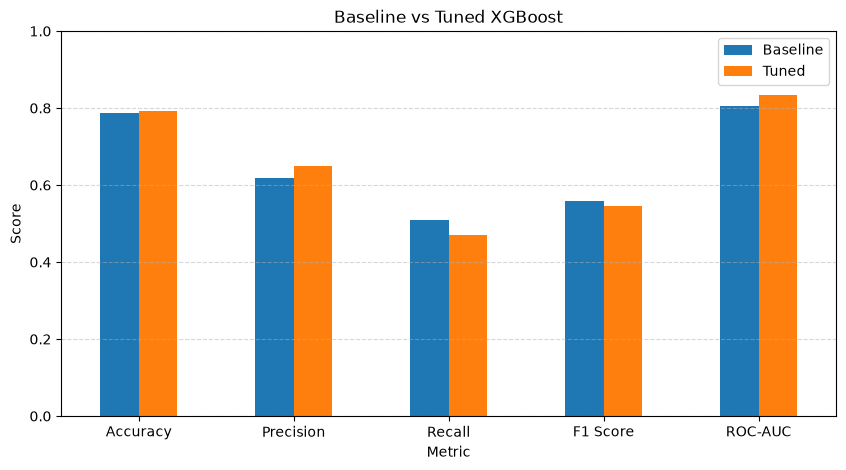

In [20]:
comparison_plot = comparison_df.set_index("Metric")[["Baseline", "Tuned"]]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Baseline vs Tuned XGBoost")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Conclusion

Hyperparameter tuning using RandomizedSearchCV improved the overall discriminative ability of the XGBoost model. The ROC-AUC score increased from **0.8047** to **0.8346**, indicating a better ability to distinguish between churn and non-churn customers across different decision thresholds.

The tuned model also achieved higher accuracy and precision, meaning its positive churn predictions became more reliable. However, recall and F1 score decreased slightly, indicating that the model identified fewer actual churners at the default classification threshold.

Overall, since the optimization objective was to maximize ROC-AUC, the tuned XGBoost model represents an improvement over the baseline and will be included in the final model comparison.